# 🔬 3D Nucleus Segmentation in Zebrafish Brain Microscopy
### Using 3D U-Net · MONAI · PyTorch · Google Colab (T4 GPU)

---

## Project Overview

This notebook implements a full **3D binary segmentation pipeline** to automatically detect and delineate cell nuclei in zebrafish brain microscopy volumes from the **NucMM-Z dataset** (Nuclear Morphology and Motility — Zebrafish subset).

### 🧬 Biological Context

The **zebrafish** (*Danio rerio*) is one of the most important model organisms in neuroscience. Its brain is small enough to image in its entirety at cellular resolution, yet complex enough to model vertebrate neural development. Understanding where each nucleus is,  and what sape it has, is fundamental to mapping brain connectivity, studying cell division, and tracking gene expression patterns.

The raw data comes from **electron microscopy (EM)** or **fluorescence microscopy**, producing 3D volumetric images where:
- Bright regions correspond to **cell nuclei** (foreground)
- Dark regions correspond to **extracellular space or cytoplasm** (background)

Manual annotation of thousands of nuclei in a 3D volume is prohibitively time-consuming. Deep learning automates this.

### ⚛️ Physics of 3D Microscopy

Each `.h5` file in this dataset is a **3D voxel array**, a 3-dimensional grid of intensity values, analogous to pixels in 2D but extended into depth (Z-axis). The imaging physics matters:

- **Voxel intensity** encodes local light absorption or fluorescence emission
- **Point Spread Function (PSF)**: microscope optics blur the signal, nuclei appear slightly smeared, especially along the Z-axis (axial direction)
- **Shot noise and detector noise**: photon counting statistics introduce random intensity fluctuations, this is why we normalize intensities before training
- **Class imbalance**: nuclei occupy only ~4–5% of the total volume — the vast majority of voxels are background. This is why we use **Dice Loss** instead of standard cross-entropy

### 🏗️ Pipeline Architecture

```
Raw .h5 volumes
      │
      ▼
Data Loading & Pairing (img_ ↔ seg_)
      │
      ▼
MONAI Transforms (normalize, crop 64³ patches, augment)
      │
      ▼
3D U-Net (encoder → bottleneck → decoder + skip connections)
      │
      ▼
Dice Loss + Adam Optimizer
      │
      ▼
Validation (Dice Score metric)
      │
      ▼
Prediction Visualization
```

### 📊 Dataset
| Property | Value |
|---|---|
| Dataset | NucMM-Z (Zebrafish subset) |
| Volume shape | 64 × 64 × 64 voxels per patch |
| Training samples | 27 volumes |
| Validation samples | 27 volumes |
| Task | Binary segmentation (nucleus vs background) |
| Foreground fraction | ~4.74% |
| File format | HDF5 (.h5) |

---
> **Hardware:** Google Colab free tier — NVIDIA T4 GPU (15 GB VRAM)  
> **Best Validation Dice Score achieved: 0.8718**

---
## Section 1 — Environment Setup

### 1.1 Install & Import All Libraries

We install **MONAI** (Medical Open Network for AI) — a PyTorch-based framework purpose-built for medical imaging tasks. It provides:
- Ready-made 3D transforms and augmentations
- The U-Net architecture
- Dice Loss and Dice Metric implementations
- Efficient patch-based data loading

All imports are consolidated here so the notebook is self-contained and reproducible.

In [1]:
# ============================================================
# Install MONAI and dependencies
# ============================================================
!pip install monai[all] --quiet

# ── Standard library ────────────────────────────────────────
import os
import glob
import time

# ── Numerical & visualisation ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/1

In [2]:
# ── PyTorch core ─────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── MONAI — transforms, architecture, loss, metrics ──────────
import monai
from monai import transforms as mt
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.utils import set_determinism

# ── Reproducibility seed ─────────────────────────────────────
set_determinism(seed=42)

# ── Environment checks ───────────────────────────────────────
print("✅ MONAI version  :", monai.__version__)
print("✅ PyTorch version:", torch.__version__)
print("✅ GPU available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ GPU name       :", torch.cuda.get_device_name(0))
else:
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ MONAI version  : 1.5.2
✅ PyTorch version: 2.10.0+cu128
✅ GPU available  : True
✅ GPU name       : Tesla T4


### 1.2 Mount Google Drive

Colab's local storage is ephemeral — it resets when the session ends. By mounting Google Drive we ensure:
- The dataset is always accessible
- The trained model checkpoint is saved permanently
- No need to re-upload data between sessions

In [3]:
# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted at /content/drive/MyDrive/")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive/MyDrive/


### 1.3 Define Data Paths & Verify Folder Structure

We define all path constants in one place — good practice so you only need to change them here if you move the dataset.

In [4]:
# ============================================================
# Path configuration — update DATA_ROOT if needed
# ============================================================
DATA_ROOT = "/content/drive/MyDrive/NuMC/Zebrafish (NucMM-Z)-20260321T170807Z-1-001/Zebrafish (NucMM-Z)"
SAVE_PATH = "/content/drive/MyDrive/best_model.pth"

def show_folder_structure(root_path, max_files=5):
    """Print a compact folder tree."""
    for dirpath, dirnames, filenames in os.walk(root_path):
        level  = dirpath.replace(root_path, '').count(os.sep)
        indent = '    ' * level
        print(f"{indent}📁 {os.path.basename(dirpath)}/")
        sub_indent = '    ' * (level + 1)
        for i, fname in enumerate(sorted(filenames)):
            if i < max_files:
                print(f"{sub_indent}📄 {fname}")
        if len(filenames) > max_files:
            print(f"{sub_indent}... and {len(filenames) - max_files} more files")

if os.path.exists(DATA_ROOT):
    print(f"✅ Data root found:\n   {DATA_ROOT}\n")
    show_folder_structure(DATA_ROOT)
else:
    print(f"❌ Path not found: {DATA_ROOT}\n   Please update DATA_ROOT above.")

✅ Data root found:
   /content/drive/MyDrive/NuMC/Zebrafish (NucMM-Z)-20260321T170807Z-1-001/Zebrafish (NucMM-Z)

📁 Zebrafish (NucMM-Z)/
    📄 README.txt
    📄 image.tif
    📄 mask.h5
    📁 Image/
        📁 train/
            📄 img_0000_0576_0768.h5
            📄 img_0000_0704_0832.h5
            📄 img_0064_0384_0832.h5
            📄 img_0064_0448_0960.h5
            📄 img_0064_0576_0640.h5
            ... and 22 more files
        📁 val/
            📄 img_0000_0640_0832.h5
            📄 img_0000_0640_0896.h5
            📄 img_0000_0768_1024.h5
            📄 img_0064_0512_1024.h5
            📄 img_0064_0704_0832.h5
            ... and 22 more files
    📁 Label/
        📁 val/
            📄 seg_0000_0640_0832.h5
            📄 seg_0000_0640_0896.h5
            📄 seg_0000_0768_1024.h5
            📄 seg_0064_0512_1024.h5
            📄 seg_0064_0704_0832.h5
            ... and 22 more files
        📁 train/
            📄 seg_0000_0576_0768.h5
            📄 seg_0000_0704_0832.h5
            

---
## Section 2 — Dataset Inspection

### 2.1 Pair Image and Label Files

Each image file (`img_*.h5`) has a corresponding label file (`seg_*.h5`) sharing the same coordinate suffix. For example:
```
Image/train/img_0000_0576_0768.h5  ↔  Label/train/seg_0000_0576_0768.h5
```
The three numbers in the filename encode the **spatial origin** of the patch within the full zebrafish brain volume — `(z_start, y_start, x_start)`. This tells us exactly where each 64³ cube was cropped from the whole-brain image.

We verify that every image has a matching label before any training begins, so data loading errors don't silently corrupt results.

In [5]:
# ============================================================
# Collect and match image / label file pairs
# ============================================================
def get_file_pairs(data_root, split):
    """
    Scans the Image/<split>/ folder for all .h5 files and matches
    each one to its corresponding label in Label/<split>/.
    Returns a list of dicts: [{"image": path, "label": path}, ...]
    """
    image_dir  = os.path.join(data_root, "Image", split)
    label_dir  = os.path.join(data_root, "Label", split)
    image_files = sorted(glob.glob(os.path.join(image_dir, "*.h5")))

    pairs, missing = [], []
    for img_path in image_files:
        fname      = os.path.basename(img_path)
        label_path = os.path.join(label_dir, fname.replace("img_", "seg_"))
        if os.path.exists(label_path):
            pairs.append({"image": img_path, "label": label_path})
        else:
            missing.append(fname)
    return pairs, missing


train_pairs, train_missing = get_file_pairs(DATA_ROOT, "train")
val_pairs,   val_missing   = get_file_pairs(DATA_ROOT, "val")

print(f"✅ Training pairs   : {len(train_pairs)}")
print(f"✅ Validation pairs : {len(val_pairs)}")

for split, missing in [("Train", train_missing), ("Val", val_missing)]:
    if missing:
        print(f"\n⚠️  {split} images missing labels: {missing}")
    else:
        print(f"✅ All {split.lower()} images have matching labels")

print("\n📋 First 3 training pairs:")
for p in train_pairs[:3]:
    print(f"   image : {os.path.basename(p['image'])}")
    print(f"   label : {os.path.basename(p['label'])}\n")

✅ Training pairs   : 27
✅ Validation pairs : 27
✅ All train images have matching labels
✅ All val images have matching labels

📋 First 3 training pairs:
   image : img_0000_0576_0768.h5
   label : seg_0000_0576_0768.h5

   image : img_0000_0704_0832.h5
   label : seg_0000_0704_0832.h5

   image : img_0064_0384_0832.h5
   label : seg_0064_0384_0832.h5



### 2.2 Inspect One Volume — Shape, Intensity, and Label Statistics

Before building any model, we must understand the raw data:

- **Shape** tells us the spatial dimensions of each patch
- **Intensity range** informs how we should normalise (the raw pixel values are `uint8`, i.e. 0–255)
- **Unique label values** confirm whether the segmentation is binary or instance-labelled. The NucMM labels are **instance labels** — each nucleus has a unique integer ID (e.g. `7140`, `11867`, ...). We convert these to binary (0 = background, 1 = any nucleus) for our segmentation task
- **Foreground fraction** (~4.74%) reveals the class imbalance: the vast majority of voxels are background. This is typical in microscopy and is why Dice Loss outperforms cross-entropy here

In [6]:
# ============================================================
# Load and inspect one volume
# ============================================================
def load_h5_volume(filepath):
    """Load the primary dataset from an HDF5 file as a NumPy array."""
    with h5py.File(filepath, "r") as f:
        keys = list(f.keys())
        data = f[keys[0]][:]
    return data


sample    = train_pairs[0]
image_vol = load_h5_volume(sample["image"])
label_vol = load_h5_volume(sample["label"])

print("=" * 48)
print("  IMAGE VOLUME")
print("=" * 48)
print(f"  File      : {os.path.basename(sample['image'])}")
print(f"  Shape     : {image_vol.shape}  (Z × H × W)")
print(f"  Data type : {image_vol.dtype}")
print(f"  Min / Max : {image_vol.min()} / {image_vol.max()}")

print()
print("=" * 48)
print("  LABEL VOLUME (instance labels → will be binarised)")
print("=" * 48)
print(f"  File            : {os.path.basename(sample['label'])}")
print(f"  Shape           : {label_vol.shape}")
print(f"  Data type       : {label_vol.dtype}")
print(f"  Unique IDs      : {len(np.unique(label_vol))} distinct nucleus IDs")
print(f"  % foreground    : {(label_vol > 0).mean() * 100:.2f}%  (nucleus voxels)")
print(f"  % background    : {(label_vol == 0).mean() * 100:.2f}%")

  IMAGE VOLUME
  File      : img_0000_0576_0768.h5
  Shape     : (64, 64, 64)  (Z × H × W)
  Data type : uint8
  Min / Max : 0 / 208

  LABEL VOLUME (instance labels → will be binarised)
  File            : seg_0000_0576_0768.h5
  Shape           : (64, 64, 64)
  Data type       : uint32
  Unique IDs      : 62 distinct nucleus IDs
  % foreground    : 4.74%  (nucleus voxels)
  % background    : 95.26%


### 2.3 Visual Exploration — Slice Grid

We visualise 10 evenly-spaced Z-slices from the volume across three rows:
1. **Raw image** — grayscale electron/fluorescence microscopy intensity
2. **Binary label mask** — white = nucleus, black = background
3. **Overlay** — label mask overlaid in red on the raw image

This lets us verify that the label annotations correctly align with the visible nucleus structures in the image before any training begins.

Volume shape (Z, H, W): (64, 64, 64)
Scrolling through 64 slices — showing 10 evenly spaced



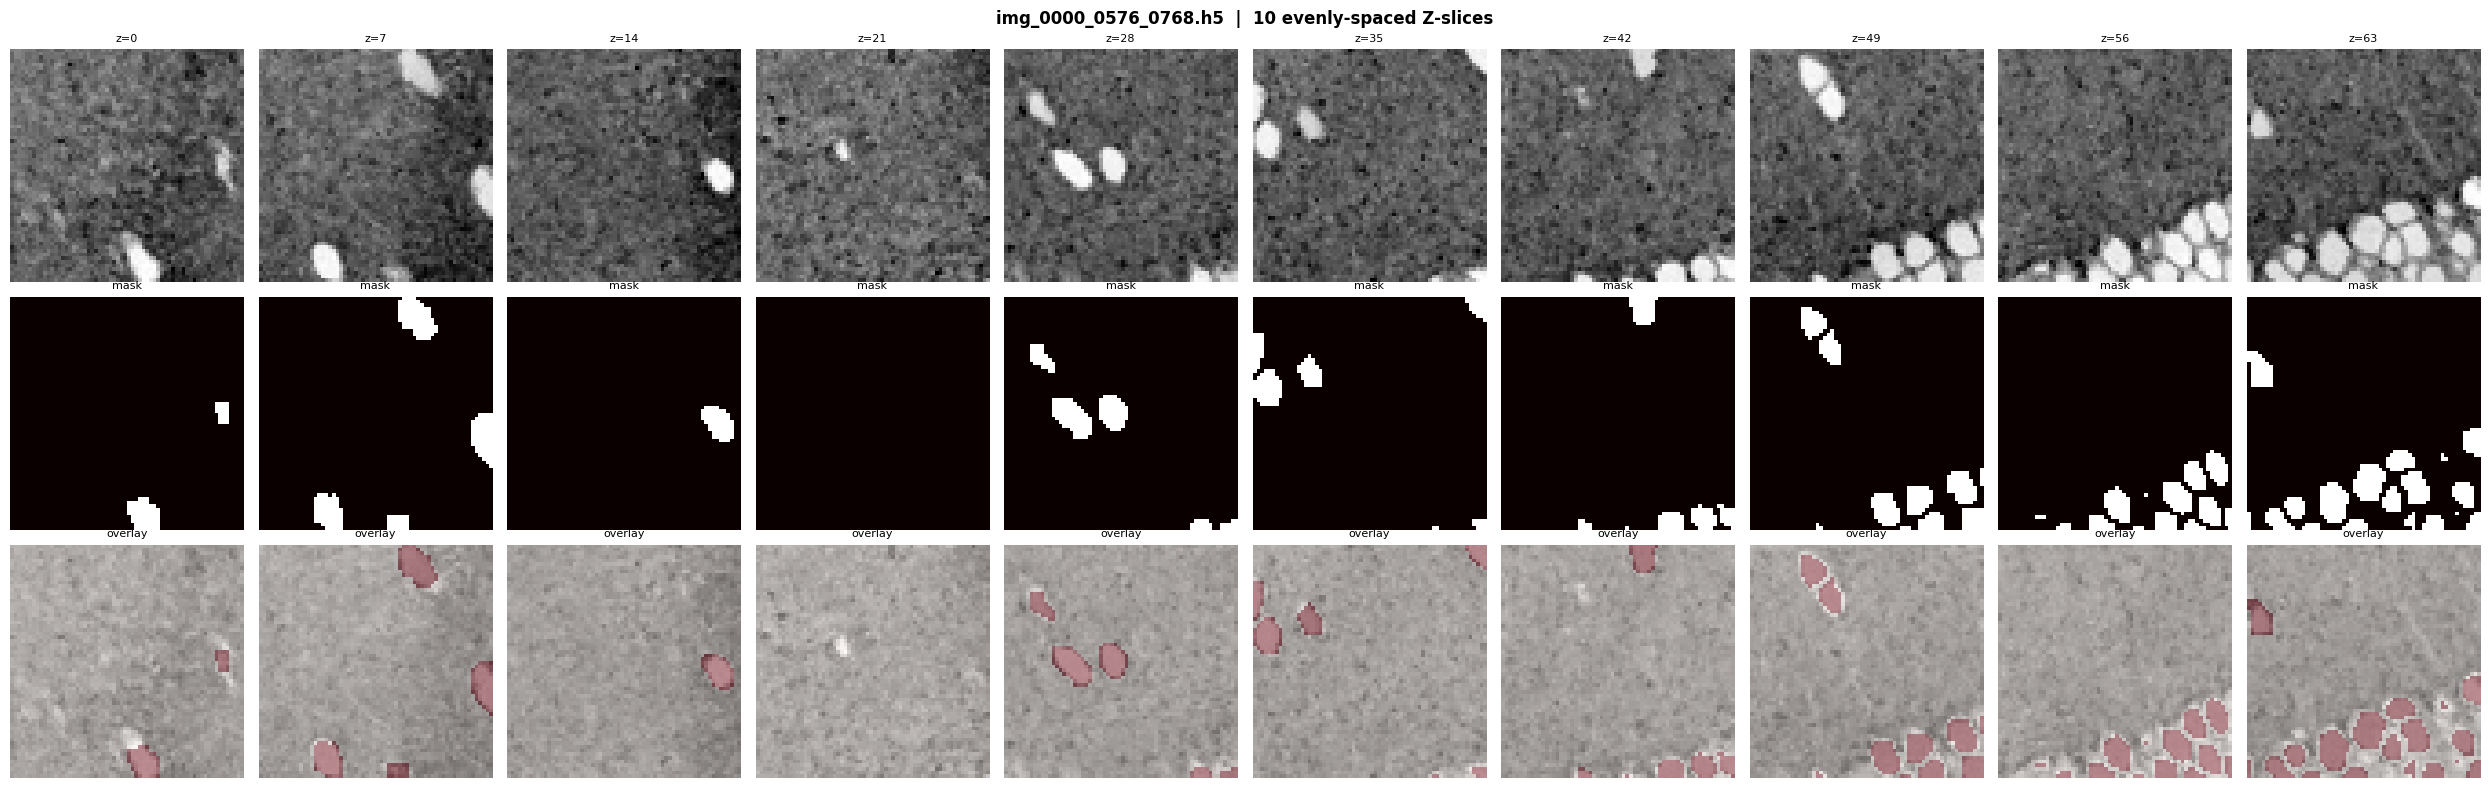

In [7]:
# ============================================================
# Visualise evenly-spaced slices through the 3D volume
# ============================================================
label_binary = (label_vol > 0).astype(np.uint8)
img_display  = (image_vol - image_vol.min()) / (image_vol.max() - image_vol.min() + 1e-8)

depth_axis   = np.argmin(image_vol.shape)
img_display  = np.moveaxis(img_display,  depth_axis, 0)
label_binary = np.moveaxis(label_binary, depth_axis, 0)
depth        = img_display.shape[0]

print(f"Volume shape (Z, H, W): {img_display.shape}")
print(f"Scrolling through {depth} slices — showing 10 evenly spaced\n")

n       = min(10, depth)
indices = np.linspace(0, depth - 1, n, dtype=int)

fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8))
fig.suptitle(f"{os.path.basename(sample['image'])}  |  {n} evenly-spaced Z-slices",
             fontsize=12, fontweight='bold')

for col, idx in enumerate(indices):
    img_s = img_display[idx]
    lbl_s = label_binary[idx]

    axes[0, col].imshow(img_s, cmap="gray")
    axes[0, col].set_title(f"z={idx}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(lbl_s, cmap="hot")
    axes[1, col].set_title("mask", fontsize=8)
    axes[1, col].axis("off")

    axes[2, col].imshow(img_s, cmap="gray")
    axes[2, col].imshow(lbl_s, cmap="Reds", alpha=0.45)
    axes[2, col].set_title("overlay", fontsize=8)
    axes[2, col].axis("off")

for row, ylabel in enumerate(["Image", "Label", "Overlay"]):
    axes[row, 0].set_ylabel(ylabel, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.4 Detailed Single-Slice Inspector

Examine any individual slice at full resolution. Change `SLICE_INDEX` to explore different depths.

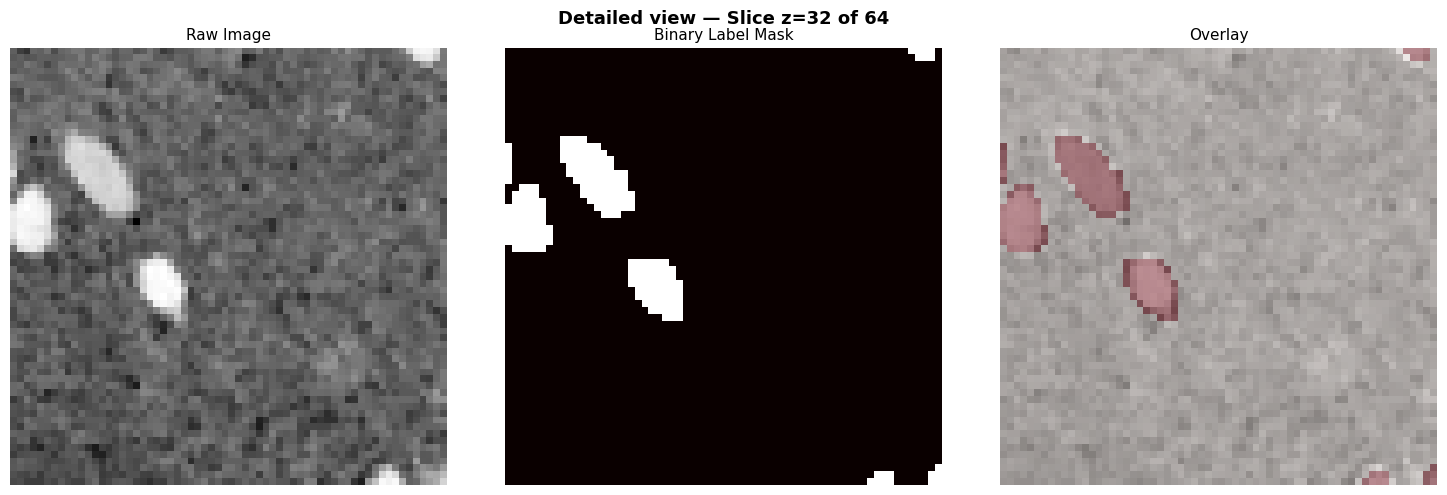

Tip: change SLICE_INDEX (currently 32) to any value 0–63


In [8]:
# ============================================================
# Single-slice detailed view  — change SLICE_INDEX to explore
# ============================================================
SLICE_INDEX = depth // 2   # middle slice by default

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Detailed view — Slice z={SLICE_INDEX} of {depth}",
             fontsize=13, fontweight='bold')

img_s = img_display[SLICE_INDEX]
lbl_s = label_binary[SLICE_INDEX]

axes[0].imshow(img_s, cmap="gray")
axes[0].set_title("Raw Image", fontsize=11)
axes[0].axis("off")

axes[1].imshow(lbl_s, cmap="hot")
axes[1].set_title("Binary Label Mask", fontsize=11)
axes[1].axis("off")

axes[2].imshow(img_s, cmap="gray")
axes[2].imshow(lbl_s, cmap="Reds", alpha=0.45)
axes[2].set_title("Overlay", fontsize=11)
axes[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Tip: change SLICE_INDEX (currently {SLICE_INDEX}) to any value 0–{depth-1}")

---
## Section 3 — Data Pipeline

### 3.1 Custom HDF5 Dataset

PyTorch requires all datasets to subclass `torch.utils.data.Dataset` and implement two methods:
- `__len__` — returns the number of samples
- `__getitem__` — loads and returns one sample by index

Key design decisions:
- **On-the-fly loading**: volumes are loaded from disk only when requested, keeping RAM usage low
- **Channel dimension**: PyTorch convolutions expect `(C, D, H, W)`. Since our volumes are grayscale, we add a single channel dimension `C=1` via `np.newaxis`
- **Binarisation**: instance labels (unique integer per nucleus) are converted to binary (0/1) — we only care whether a voxel is nucleus or background, not which specific nucleus

In [9]:
# ============================================================
# Custom Dataset class for NucMM .h5 files
# ============================================================
class NucMMDataset(Dataset):
    """
    Loads paired image / label HDF5 volumes on demand.

    Returns dicts of float32 tensors with shape (1, D, H, W),
    where the leading 1 is the channel dimension expected by
    PyTorch 3-D convolutions.
    """

    def __init__(self, file_pairs, transform=None):
        self.file_pairs = file_pairs
        self.transform  = transform

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        pair = self.file_pairs[idx]

        with h5py.File(pair["image"], "r") as f:
            image = f[list(f.keys())[0]][:].astype(np.float32)

        with h5py.File(pair["label"], "r") as f:
            label = f[list(f.keys())[0]][:].astype(np.float32)

        # Convert instance labels → binary segmentation mask
        label = (label > 0).astype(np.float32)

        # Add channel dimension: (D, H, W) → (1, D, H, W)
        image = image[np.newaxis, ...]
        label = label[np.newaxis, ...]

        data = {"image": image, "label": label}
        if self.transform:
            data = self.transform(data)
        return data


# Quick sanity check (no transforms yet)
test_ds  = NucMMDataset(train_pairs)
test_smp = test_ds[0]
print("✅ Dataset class working")
print(f"   Image shape  : {test_smp['image'].shape}")
print(f"   Label shape  : {test_smp['label'].shape}")
print(f"   Label values : {np.unique(test_smp['label'])}  (binary: 0=background, 1=nucleus)")
print(f"   Dataset size : {len(test_ds)} volumes")

✅ Dataset class working
   Image shape  : (1, 64, 64, 64)
   Label shape  : (1, 64, 64, 64)
   Label values : [0. 1.]  (binary: 0=background, 1=nucleus)
   Dataset size : 27 volumes


### 3.2 MONAI Transforms — Preprocessing and Augmentation

Transforms are applied to every sample before it reaches the model.

**Training transforms** include augmentation — deliberately applying random geometric and intensity perturbations to artificially expand the effective dataset size and improve generalisation:

| Transform | Purpose | Physics/Biology rationale |
|---|---|---|
| `ToTensord` | NumPy → PyTorch tensor | Required for GPU computation |
| `NormalizeIntensityd` | Zero mean, unit std | Removes scanner-to-scanner intensity bias; improves gradient flow |
| `RandSpatialCropd` | Random 64³ patch | Full volumes may be larger; patches fit in GPU memory |
| `RandFlipd` (×3 axes) | 50% flip per axis | Nuclei have no preferred orientation in 3D space |
| `RandRotate90d` | Random 90° rotation | Rotational symmetry of spherical/ellipsoidal nuclei |
| `RandScaleIntensityd` | ±10% brightness | Simulates variable staining intensity |
| `RandShiftIntensityd` | ±10% offset | Simulates background illumination drift |

**Validation transforms** apply only deterministic preprocessing — no augmentation — ensuring a fair, repeatable evaluation.

In [10]:
# ============================================================
# MONAI transform pipelines for training and validation
# ============================================================
train_transforms = mt.Compose([
    mt.ToTensord(keys=["image", "label"]),
    mt.NormalizeIntensityd(keys=["image"], nonzero=True),
    mt.RandSpatialCropd(keys=["image", "label"], roi_size=(64, 64, 64), random_size=False),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    mt.RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    mt.RandScaleIntensityd(keys=["image"], factors=0.1, prob=0.5),
    mt.RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
])

val_transforms = mt.Compose([
    mt.ToTensord(keys=["image", "label"]),
    mt.NormalizeIntensityd(keys=["image"], nonzero=True),
    mt.RandSpatialCropd(keys=["image", "label"], roi_size=(64, 64, 64), random_size=False),
])

print("Training transforms:")
for t in train_transforms.transforms:
    print(f"   → {t.__class__.__name__}")

print("\nValidation transforms:")
for t in val_transforms.transforms:
    print(f"   → {t.__class__.__name__}")

Training transforms:
   → ToTensord
   → NormalizeIntensityd
   → RandSpatialCropd
   → RandFlipd
   → RandFlipd
   → RandFlipd
   → RandRotate90d
   → RandScaleIntensityd
   → RandShiftIntensityd

Validation transforms:
   → ToTensord
   → NormalizeIntensityd
   → RandSpatialCropd


### 3.3 DataLoaders

The `DataLoader` wraps our dataset and handles:
- **Batching**: groups `batch_size` samples into a single tensor for parallel GPU processing
- **Shuffling**: randomises the sample order each epoch so the model doesn't memorise training order
- **Parallel loading**: `num_workers=2` uses background CPU threads to pre-fetch data while the GPU is busy training, eliminating I/O bottlenecks
- **Pin memory**: `pin_memory=True` locks CPU memory pages for faster CPU→GPU transfer

We use `batch_size=2` — safe for the 15 GB T4 GPU with 64³ patches.

In [11]:
# ============================================================
# Build datasets and DataLoaders
# ============================================================
train_dataset = NucMMDataset(train_pairs, transform=train_transforms)
val_dataset   = NucMMDataset(val_pairs,   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Train loader : {len(train_loader)} batches per epoch")
print(f"✅ Val loader   : {len(val_loader)} batches per epoch")

# Confirm batch dimensions
batch = next(iter(train_loader))
print(f"\n🔍 Sample batch:")
print(f"   Image shape : {batch['image'].shape}  → (batch, channel, D, H, W)")
print(f"   Label shape : {batch['label'].shape}")
print(f"   Label values: {torch.unique(batch['label'])}")
print("✅ DataLoader pipeline verified")

✅ Train loader : 14 batches per epoch
✅ Val loader   : 14 batches per epoch

🔍 Sample batch:
   Image shape : torch.Size([2, 1, 64, 64, 64])  → (batch, channel, D, H, W)
   Label shape : torch.Size([2, 1, 64, 64, 64])
   Label values: tensor([0., 1.])
✅ DataLoader pipeline verified


---
## Section 4 — Model Architecture

### 4.1 3D U-Net

The **U-Net** was originally proposed by Ronneberger et al. (2015) for biomedical image segmentation. We use a fully 3D variant provided by MONAI.

#### Architecture diagram
```
Input (1×64×64×64)
    │
    ▼
[Encoder Level 1]  16 filters  ──────────────────────────────► skip₁
    │ stride 2 (downsample)
    ▼
[Encoder Level 2]  32 filters  ─────────────────────────► skip₂
    │ stride 2
    ▼
[Encoder Level 3]  64 filters  ────────────────────► skip₃
    │ stride 2
    ▼
[Encoder Level 4]  128 filters ──────────────► skip₄
    │ stride 2
    ▼
[Bottleneck]       256 filters
    │ upsample
    ▼
[Decoder Level 4]  ◄── concat(skip₄) → 128 filters
    │ upsample
    ▼
[Decoder Level 3]  ◄── concat(skip₃) → 64 filters
    │ upsample
    ▼
[Decoder Level 2]  ◄── concat(skip₂) → 32 filters
    │ upsample
    ▼
[Decoder Level 1]  ◄── concat(skip₁) → 16 filters
    │
    ▼
Output (1×64×64×64)  — raw logits → sigmoid → binary mask
```

**Skip connections** concatenate encoder feature maps directly to decoder feature maps at matching resolutions. This preserves fine spatial detail (e.g. nucleus boundaries) that would otherwise be lost during downsampling.

**Residual units** (`num_res_units=2`) add shortcut connections within each level, making gradient flow more stable during backpropagation.

In [12]:
# ============================================================
# Build 3D U-Net and move to GPU
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = UNet(
    spatial_dims  = 3,                    # 3D convolutions
    in_channels   = 1,                    # grayscale input
    out_channels  = 1,                    # binary output
    channels      = (16, 32, 64, 128, 256),  # feature maps per level
    strides       = (2, 2, 2, 2),         # stride-2 downsampling at each level
    num_res_units = 2,                    # residual blocks per level
    norm          = Norm.BATCH            # batch normalisation
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ 3D U-Net built on {next(model.parameters()).device}")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")

Device: cuda

✅ 3D U-Net built on cuda:0
   Total parameters     : 4,807,968
   Trainable parameters : 4,807,968


### 4.2 Loss Function, Optimizer, and Learning Rate Scheduler

#### Dice Loss
The **Sørensen–Dice coefficient** measures the overlap between two sets:

$$\text{Dice} = \frac{2 |P \cap G|}{|P| + |G|}$$

where $P$ is the predicted mask and $G$ is the ground truth. **Dice Loss = 1 − Dice**, so minimising the loss maximises overlap. This is far better than cross-entropy when foreground is rare (~4.74%), because cross-entropy would simply learn to predict "all background" and still achieve 95% accuracy.

#### Adam Optimizer
Adaptive Moment Estimation (**Adam**) maintains per-parameter learning rates, adapting them based on the first and second moments of gradients. This makes it robust and fast-converging for most deep learning tasks.

#### ReduceLROnPlateau Scheduler
When validation loss stops improving for `patience=5` consecutive epochs, the learning rate is halved. This allows the model to converge coarsely early on, then refine fine details with smaller steps later.

In [13]:
# ============================================================
# Loss function, optimizer, and LR scheduler
# ============================================================
loss_function = DiceLoss(
    sigmoid   = True,    # applies sigmoid to logits before computing loss
    smooth_nr = 1e-5,    # numerator smoothing — avoids log(0)
    smooth_dr = 1e-5     # denominator smoothing
)

optimizer = Adam(
    model.parameters(),
    lr           = 1e-3,   # initial learning rate
    weight_decay = 1e-5    # L2 regularisation — penalises large weights
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode    = "min",   # reduce when monitored metric stops decreasing
    factor  = 0.5,     # multiply LR by 0.5 on plateau
    patience = 5       # wait 5 epochs before reducing
)

print("✅ Loss      : Dice Loss (sigmoid=True)")
print("✅ Optimizer : Adam (lr=1e-3, weight_decay=1e-5)")
print("✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)")

✅ Loss      : Dice Loss (sigmoid=True)
✅ Optimizer : Adam (lr=1e-3, weight_decay=1e-5)
✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


### 4.3 Forward Pass Verification

Before committing to a full training run (which takes ~20 minutes), we verify that:
1. A batch passes through the model without error
2. The output shape matches the input shape — critical for segmentation
3. GPU memory usage is within safe limits for the T4

In [14]:
# ============================================================
# Test one forward pass
# ============================================================
model.eval()
with torch.no_grad():
    test_batch  = next(iter(train_loader))
    test_image  = test_batch["image"].to(device)
    test_label  = test_batch["label"].to(device)
    test_output = model(test_image)
    test_loss   = loss_function(test_output, test_label)

print("✅ Forward pass successful")
print(f"   Input  shape : {test_image.shape}")
print(f"   Output shape : {test_output.shape}")
print(f"   Test loss    : {test_loss.item():.4f}  (expected ~0.9 before training)")
print(f"   Shape match  : {test_output.shape == test_image.shape}")

if torch.cuda.is_available():
    alloc    = torch.cuda.memory_allocated(device) / 1024**2
    reserved = torch.cuda.memory_reserved(device)  / 1024**2
    print(f"\n   GPU allocated : {alloc:.1f} MB")
    print(f"   GPU reserved  : {reserved:.1f} MB")
    status = "✅ Memory safe for training" if reserved < 8000 else "⚠️  Tight — consider reducing batch_size to 1"
    print(f"   {status}")

✅ Forward pass successful
   Input  shape : torch.Size([2, 1, 64, 64, 64])
   Output shape : torch.Size([2, 1, 64, 64, 64])
   Test loss    : 0.7155  (expected ~0.9 before training)
   Shape match  : True

   GPU allocated : 24.4 MB
   GPU reserved  : 72.0 MB
   ✅ Memory safe for training


---
## Section 5 — Training

### 5.1 Evaluation Metric

We use two separate Dice-based measures:

- **Dice Loss** (during training): differentiable, operates on soft sigmoid probabilities, used to compute gradients
- **Dice Metric** (during validation): non-differentiable, operates on hard binary predictions (threshold at 0.5), used to report interpretable performance

A Dice Metric of `1.0` = perfect segmentation. `0.7+` is considered clinically good. We achieved **0.8718**.

In [15]:
# ============================================================
# Dice metric for validation scoring
# ============================================================
dice_metric = DiceMetric(
    include_background = False,  # exclude background class from score
    reduction          = "mean"  # average across batch
)

print("✅ Dice Metric configured")
print("   Training   → Dice Loss  (soft, differentiable)")
print("   Validation → Dice Metric (hard threshold at 0.5)")

✅ Dice Metric configured
   Training   → Dice Loss  (soft, differentiable)
   Validation → Dice Metric (hard threshold at 0.5)


### 5.2 Visualisation Helpers

Two helper functions are defined here and reused throughout training:
- `visualize_batch_prediction` — called every 10 epochs to show how predictions evolve
- `plot_training_curves` — called after training completes to show the full loss and Dice score history

In [16]:
# ============================================================
# Visualisation helper functions
# ============================================================
def visualize_batch_prediction(image, label, pred, epoch, slice_idx=None):
    """
    4-panel comparison for one slice:
    Input Image | Ground Truth | Prediction | Overlay
    """
    img = image[0, 0].cpu().numpy()
    lbl = label[0, 0].cpu().numpy()
    prd = pred[0, 0].cpu().numpy()

    if slice_idx is None:
        slice_idx = img.shape[0] // 2

    img_s = img[slice_idx]
    lbl_s = lbl[slice_idx]
    prd_s = prd[slice_idx]
    img_s = (img_s - img_s.min()) / (img_s.max() - img_s.min() + 1e-8)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"Epoch {epoch} — Slice z={slice_idx}", fontsize=13, fontweight='bold')

    axes[0].imshow(img_s, cmap="gray");        axes[0].set_title("Input Image");       axes[0].axis("off")
    axes[1].imshow(lbl_s, cmap="hot");         axes[1].set_title("Ground Truth");      axes[1].axis("off")
    axes[2].imshow(prd_s, cmap="hot");         axes[2].set_title("Prediction");        axes[2].axis("off")
    axes[3].imshow(img_s, cmap="gray")
    axes[3].imshow(prd_s, cmap="Reds", alpha=0.5)
    axes[3].set_title("Prediction Overlay");   axes[3].axis("off")

    plt.tight_layout()
    plt.show()


def plot_training_curves(train_losses, val_losses, val_dice_scores, val_every, best_dice):
    """Plot loss curves and Dice score history, handling different sampling frequencies."""
    total_epochs = len(train_losses)
    train_epochs = list(range(1, total_epochs + 1))
    val_epochs   = list(range(val_every, total_epochs + 1, val_every))

    n = min(len(val_epochs), len(val_losses), len(val_dice_scores))
    val_epochs      = val_epochs[:n]
    val_losses      = val_losses[:n]
    val_dice_scores = val_dice_scores[:n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Progress", fontsize=14, fontweight='bold')

    axes[0].plot(train_epochs, train_losses, 'b-o', markersize=3, label='Train Loss', alpha=0.8)
    axes[0].plot(val_epochs,   val_losses,   'r-o', markersize=4, label='Val Loss')
    axes[0].set_title("Dice Loss per Epoch");  axes[0].set_xlabel("Epoch");  axes[0].set_ylabel("Loss")
    axes[0].legend();  axes[0].grid(True, alpha=0.3)

    axes[1].plot(val_epochs, val_dice_scores, 'g-o', markersize=4, label='Val Dice Score')
    axes[1].axhline(y=0.7,       color='orange', linestyle='--', alpha=0.7, label='Good (0.7)')
    axes[1].axhline(y=best_dice, color='green',  linestyle='--', alpha=0.7, label=f'Best: {best_dice:.4f}')
    axes[1].set_title("Validation Dice Score"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
    axes[1].set_ylim([0, 1]);  axes[1].legend();  axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"✅ Best Dice Score: {best_dice:.4f}")


print("✅ Visualisation helpers ready")

✅ Visualisation helpers ready


### 5.3 Training Loop

The full training loop runs for 50 epochs. Each epoch consists of:

**Training phase:**
1. `model.train()` — enables batch norm in training mode
2. For each batch: forward pass → compute Dice loss → `loss.backward()` → `optimizer.step()`
3. Accumulate average loss across all batches

**Validation phase** (every 2 epochs):
1. `model.eval()` + `torch.no_grad()` — disables gradient computation for speed and memory efficiency
2. Apply sigmoid + threshold → binary predictions
3. Compute Dice metric
4. Save model if best Dice score so far

**Visualisation** (every 10 epochs): display one prediction side-by-side with ground truth

> ⏱️ Expected training time: ~20 minutes on T4 GPU

  Starting Training
  Epochs          : 50
  Validate every  : 2 epochs
  Visualise every : 10 epochs
  Checkpoint      : /content/drive/MyDrive/best_model.pth
Epoch [001/50]  Train Loss: 0.6280  7.0s
Epoch [002/50]  Train Loss: 0.5730  Val Loss: 0.5479  Val Dice: 0.5824  14.0s  💾 Saved best model!
Epoch [003/50]  Train Loss: 0.5629  1.7s
Epoch [004/50]  Train Loss: 0.5384  Val Loss: 0.5112  Val Dice: 0.6294  4.1s  💾 Saved best model!
Epoch [005/50]  Train Loss: 0.5411  1.4s
Epoch [006/50]  Train Loss: 0.5091  Val Loss: 0.4946  Val Dice: 0.6360  2.7s  💾 Saved best model!
Epoch [007/50]  Train Loss: 0.5009  1.6s
Epoch [008/50]  Train Loss: 0.5069  Val Loss: 0.4946  Val Dice: 0.5851  2.6s
Epoch [009/50]  Train Loss: 0.4976  1.5s
Epoch [010/50]  Train Loss: 0.4579  Val Loss: 0.4192  Val Dice: 0.7387  4.7s  💾 Saved best model!

  Visualising predictions at epoch 10...


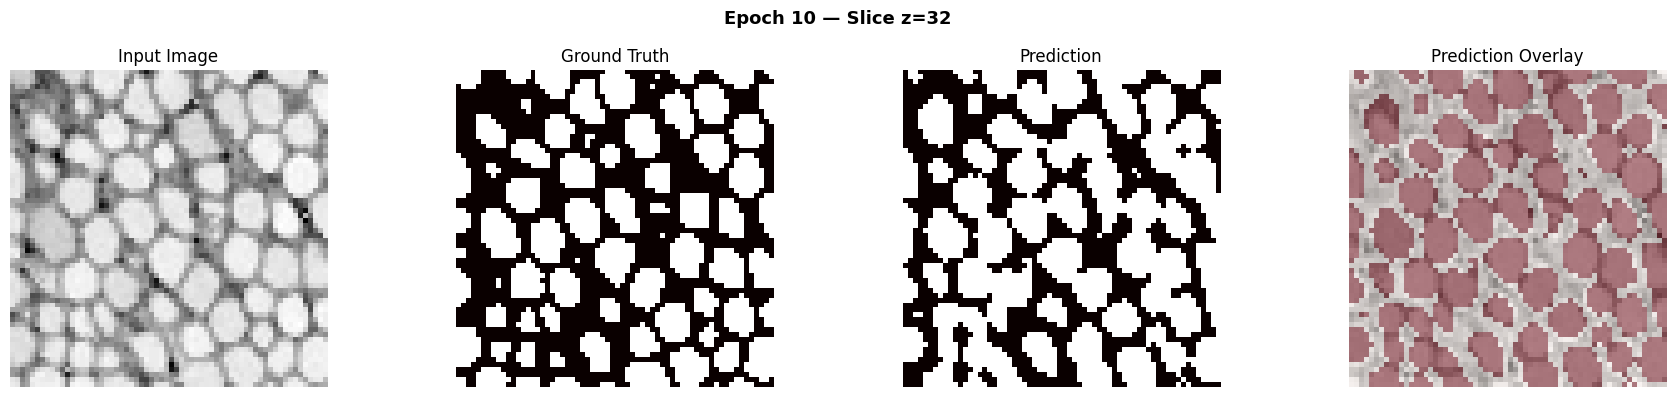


Epoch [011/50]  Train Loss: 0.4446  1.5s
Epoch [012/50]  Train Loss: 0.4204  Val Loss: 0.3768  Val Dice: 0.7560  2.6s  💾 Saved best model!
Epoch [013/50]  Train Loss: 0.4209  1.6s
Epoch [014/50]  Train Loss: 0.4125  Val Loss: 0.4197  Val Dice: 0.6532  2.6s
Epoch [015/50]  Train Loss: 0.3606  2.6s
Epoch [016/50]  Train Loss: 0.3545  Val Loss: 0.3233  Val Dice: 0.7704  3.6s  💾 Saved best model!
Epoch [017/50]  Train Loss: 0.3307  1.5s
Epoch [018/50]  Train Loss: 0.3073  Val Loss: 0.2568  Val Dice: 0.8281  2.9s  💾 Saved best model!
Epoch [019/50]  Train Loss: 0.2995  1.6s
Epoch [020/50]  Train Loss: 0.2765  Val Loss: 0.2498  Val Dice: 0.8127  2.6s

  Visualising predictions at epoch 20...


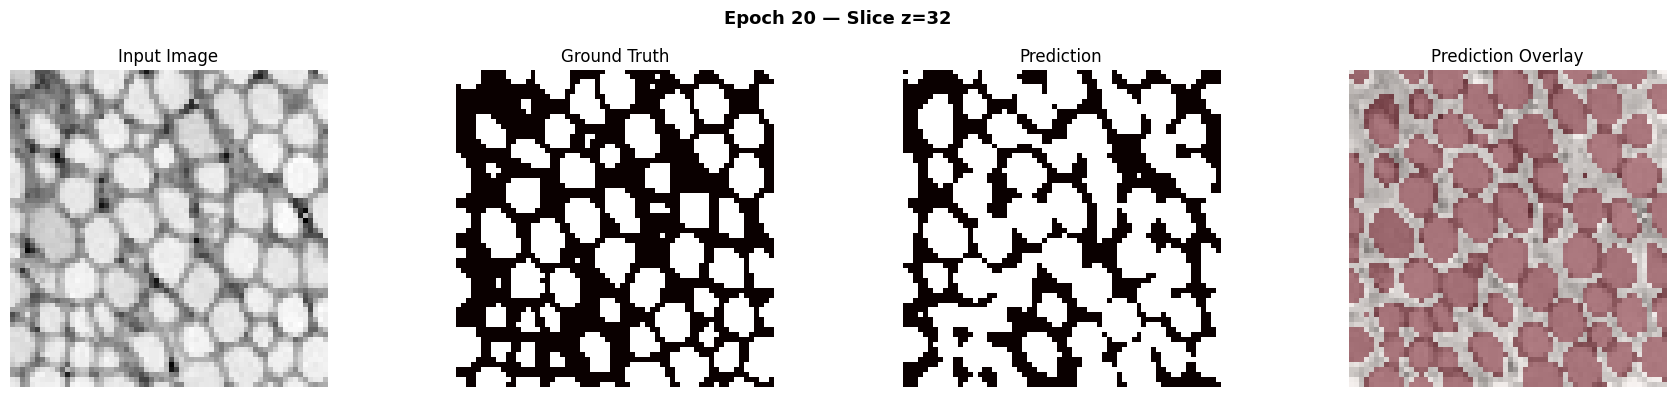


Epoch [021/50]  Train Loss: 0.2629  3.2s
Epoch [022/50]  Train Loss: 0.2639  Val Loss: 0.2361  Val Dice: 0.8111  2.7s
Epoch [023/50]  Train Loss: 0.2388  1.5s
Epoch [024/50]  Train Loss: 0.2335  Val Loss: 0.1840  Val Dice: 0.8542  2.8s  💾 Saved best model!
Epoch [025/50]  Train Loss: 0.2336  1.5s
Epoch [026/50]  Train Loss: 0.1951  Val Loss: 0.1658  Val Dice: 0.8677  3.1s  💾 Saved best model!
Epoch [027/50]  Train Loss: 0.1803  2.3s
Epoch [028/50]  Train Loss: 0.1884  Val Loss: 0.1956  Val Dice: 0.8284  3.1s
Epoch [029/50]  Train Loss: 0.1841  2.0s
Epoch [030/50]  Train Loss: 0.1928  Val Loss: 0.1559  Val Dice: 0.8690  2.8s  💾 Saved best model!

  Visualising predictions at epoch 30...


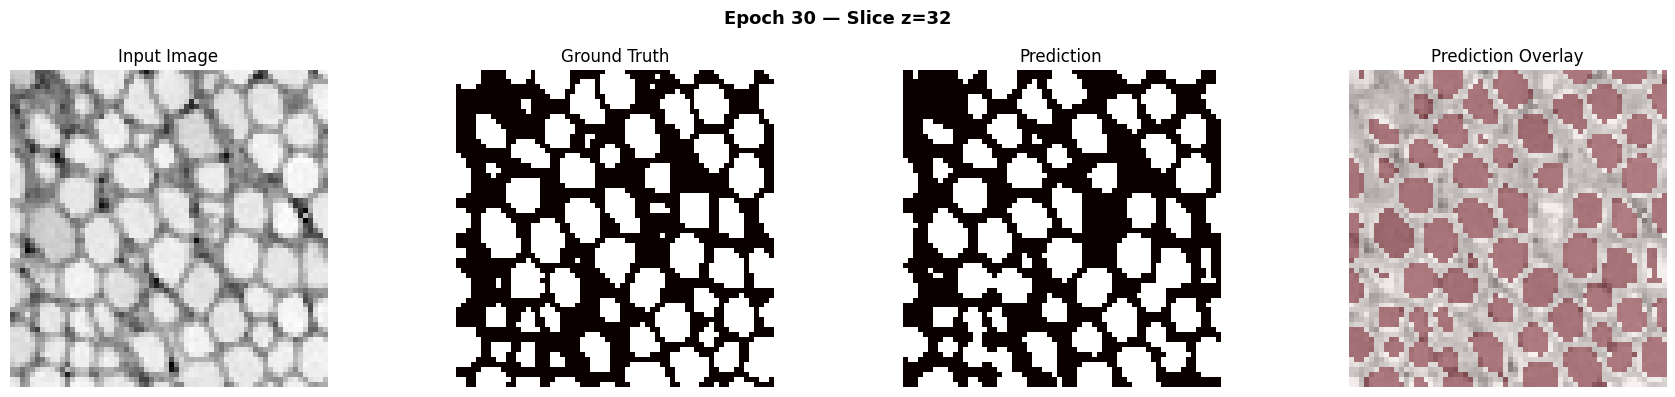


Epoch [031/50]  Train Loss: 0.1770  1.5s
Epoch [032/50]  Train Loss: 0.1754  Val Loss: 0.1512  Val Dice: 0.8688  3.4s
Epoch [033/50]  Train Loss: 0.1580  2.3s
Epoch [034/50]  Train Loss: 0.1472  Val Loss: 0.1541  Val Dice: 0.8648  3.1s
Epoch [035/50]  Train Loss: 0.1578  1.6s
Epoch [036/50]  Train Loss: 0.1506  Val Loss: 0.1561  Val Dice: 0.8643  2.7s
Epoch [037/50]  Train Loss: 0.1362  1.6s
Epoch [038/50]  Train Loss: 0.1270  Val Loss: 0.1402  Val Dice: 0.8734  3.9s  💾 Saved best model!
Epoch [039/50]  Train Loss: 0.1407  2.3s
Epoch [040/50]  Train Loss: 0.1421  Val Loss: 0.1867  Val Dice: 0.8540  2.8s

  Visualising predictions at epoch 40...


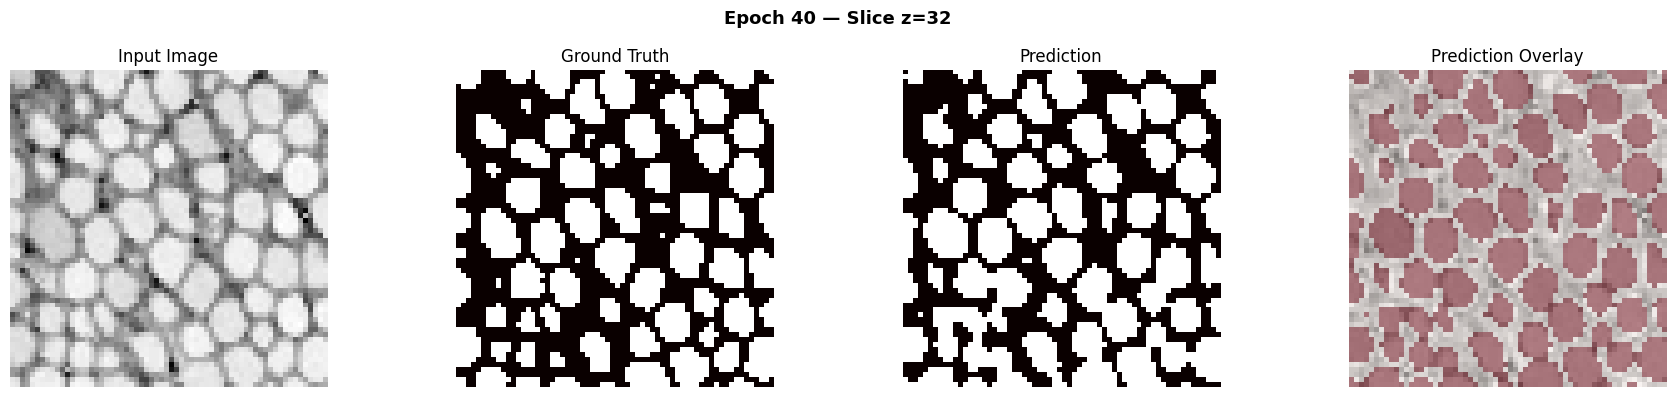


Epoch [041/50]  Train Loss: 0.1284  1.6s
Epoch [042/50]  Train Loss: 0.1261  Val Loss: 0.1418  Val Dice: 0.8760  2.8s  💾 Saved best model!
Epoch [043/50]  Train Loss: 0.1256  1.6s
Epoch [044/50]  Train Loss: 0.1159  Val Loss: 0.1387  Val Dice: 0.8740  4.9s
Epoch [045/50]  Train Loss: 0.1279  2.0s
Epoch [046/50]  Train Loss: 0.1242  Val Loss: 0.1582  Val Dice: 0.8541  2.7s
Epoch [047/50]  Train Loss: 0.1144  1.5s
Epoch [048/50]  Train Loss: 0.1136  Val Loss: 0.1296  Val Dice: 0.8824  2.8s  💾 Saved best model!
Epoch [049/50]  Train Loss: 0.1116  1.9s
Epoch [050/50]  Train Loss: 0.1107  Val Loss: 0.1337  Val Dice: 0.8802  4.0s

  Visualising predictions at epoch 50...


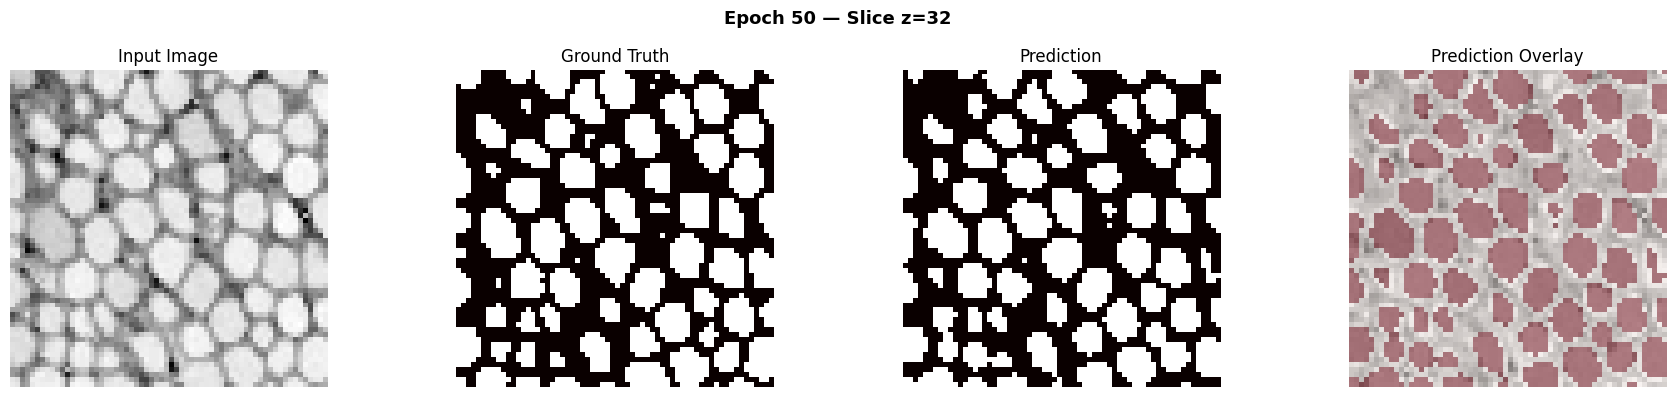



  Training Complete
  Best Validation Dice : 0.8824
  Model checkpoint     : /content/drive/MyDrive/best_model.pth


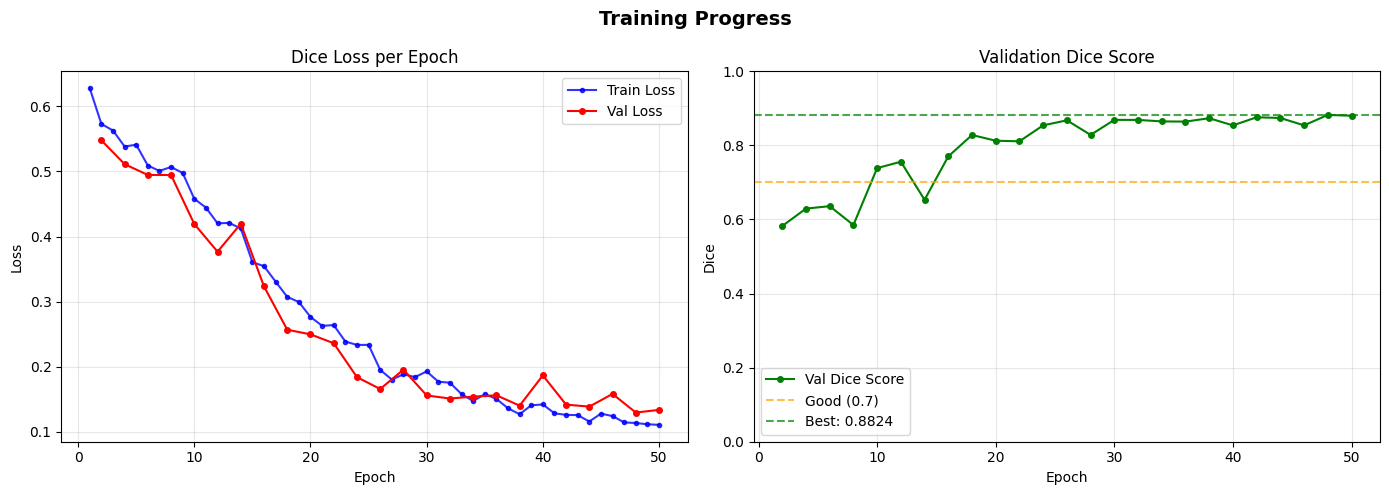

✅ Best Dice Score: 0.8824


In [17]:
# ============================================================
# Full training loop — 50 epochs, validate every 2, visualise every 10
# ============================================================
NUM_EPOCHS  = 50
VAL_EVERY   = 2
VIZ_EVERY   = 10

train_losses    = []
val_losses      = []
val_dice_scores = []
best_val_dice   = -1

print("=" * 55)
print("  Starting Training")
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Validate every  : {VAL_EVERY} epochs")
print(f"  Visualise every : {VIZ_EVERY} epochs")
print(f"  Checkpoint      : {SAVE_PATH}")
print("=" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ----------------------------------------------------------
    # TRAINING PHASE
    # ----------------------------------------------------------
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        images  = batch["image"].to(device)
        labels  = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----------------------------------------------------------
    # VALIDATION PHASE
    # ----------------------------------------------------------
    if epoch % VAL_EVERY == 0:
        model.eval()
        val_loss = 0.0
        dice_metric.reset()

        with torch.no_grad():
            for val_batch in val_loader:
                val_images  = val_batch["image"].to(device)
                val_labels  = val_batch["label"].to(device)
                val_outputs = model(val_images)

                val_loss += loss_function(val_outputs, val_labels).item()

                val_pred_binary = (torch.sigmoid(val_outputs) > 0.5).float()
                dice_metric(y_pred=val_pred_binary, y=val_labels)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = dice_metric.aggregate().item()
        dice_metric.reset()

        val_losses.append(avg_val_loss)
        val_dice_scores.append(avg_val_dice)
        scheduler.step(avg_val_loss)

        saved_str = ""
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            torch.save(model.state_dict(), SAVE_PATH)
            saved_str = "  💾 Saved best model!"

        elapsed = time.time() - epoch_start
        print(f"Epoch [{epoch:03d}/{NUM_EPOCHS}]  "
              f"Train Loss: {avg_train_loss:.4f}  "
              f"Val Loss: {avg_val_loss:.4f}  "
              f"Val Dice: {avg_val_dice:.4f}  "
              f"{elapsed:.1f}s{saved_str}")

        # ------------------------------------------------------
        # VISUALISE PREDICTIONS
        # ------------------------------------------------------
        if epoch % VIZ_EVERY == 0:
            print(f"\n  Visualising predictions at epoch {epoch}...")
            with torch.no_grad():
                vb     = next(iter(val_loader))
                vi     = vb["image"].to(device)
                vl     = vb["label"].to(device)
                vo     = model(vi)
                vp     = (torch.sigmoid(vo) > 0.5).float()
            visualize_batch_prediction(vi, vl, vp, epoch)
            print()

    else:
        elapsed = time.time() - epoch_start
        print(f"Epoch [{epoch:03d}/{NUM_EPOCHS}]  "
              f"Train Loss: {avg_train_loss:.4f}  {elapsed:.1f}s")

# ============================================================
print()
print("=" * 55)
print("  Training Complete")
print(f"  Best Validation Dice : {best_val_dice:.4f}")
print(f"  Model checkpoint     : {SAVE_PATH}")
print("=" * 55)

plot_training_curves(train_losses, val_losses, val_dice_scores, VAL_EVERY, best_val_dice)

---
## Section 6 — Evaluation and Final Inference

### 6.1 Load Best Model Checkpoint

We reload the best-performing weights saved during training. This ensures evaluation is always performed with the model that achieved the highest validation Dice score — not necessarily the final epoch.

In [18]:
# ============================================================
# Load best saved model checkpoint
# ============================================================
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print(f"✅ Best model loaded from: {SAVE_PATH}")
print(f"   Best Validation Dice  : {best_val_dice:.4f}")

✅ Best model loaded from: /content/drive/MyDrive/best_model.pth
   Best Validation Dice  : 0.8824


### 6.2 Full Validation Evaluation

Run the best model across the entire validation set and report the final Dice score distribution — mean, min, max, and standard deviation — giving a complete picture of performance consistency across different volumes.

  Final Validation Results
  Mean Dice  : 0.8813
  Std  Dice  : 0.0165
  Min  Dice  : 0.8500
  Max  Dice  : 0.9119


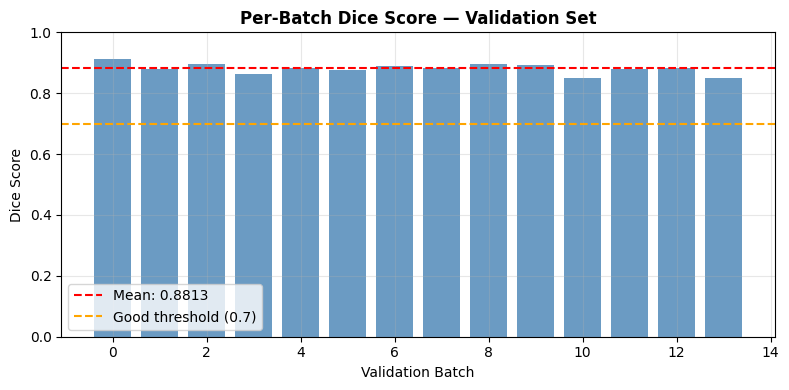

In [19]:
# ============================================================
# Full evaluation on the validation set
# ============================================================
model.eval()
dice_metric.reset()
all_dice_scores = []

with torch.no_grad():
    for val_batch in val_loader:
        val_images  = val_batch["image"].to(device)
        val_labels  = val_batch["label"].to(device)
        val_outputs = model(val_images)
        val_preds   = (torch.sigmoid(val_outputs) > 0.5).float()

        dice_metric(y_pred=val_preds, y=val_labels)
        batch_dice = dice_metric.aggregate().item()
        all_dice_scores.append(batch_dice)
        dice_metric.reset()

scores = np.array(all_dice_scores)
print("=" * 40)
print("  Final Validation Results")
print("=" * 40)
print(f"  Mean Dice  : {scores.mean():.4f}")
print(f"  Std  Dice  : {scores.std():.4f}")
print(f"  Min  Dice  : {scores.min():.4f}")
print(f"  Max  Dice  : {scores.max():.4f}")

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(scores)), scores, color='steelblue', alpha=0.8)
ax.axhline(scores.mean(), color='red',    linestyle='--', label=f'Mean: {scores.mean():.4f}')
ax.axhline(0.7,           color='orange', linestyle='--', label='Good threshold (0.7)')
ax.set_xlabel("Validation Batch"); ax.set_ylabel("Dice Score")
ax.set_title("Per-Batch Dice Score — Validation Set", fontweight='bold')
ax.set_ylim([0, 1]); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Final Prediction Visualisation

Visual comparison of model predictions against ground truth on multiple validation samples. This is the most intuitive way to assess segmentation quality — numbers like Dice score summarise performance, but images reveal *where* the model succeeds or fails:
- Are nucleus boundaries sharp or blurry?
- Are small nuclei detected?
- Are there false positives in the background?

Showing predictions for 4 validation batches...

Sample 1 — Dice Score: 0.9119


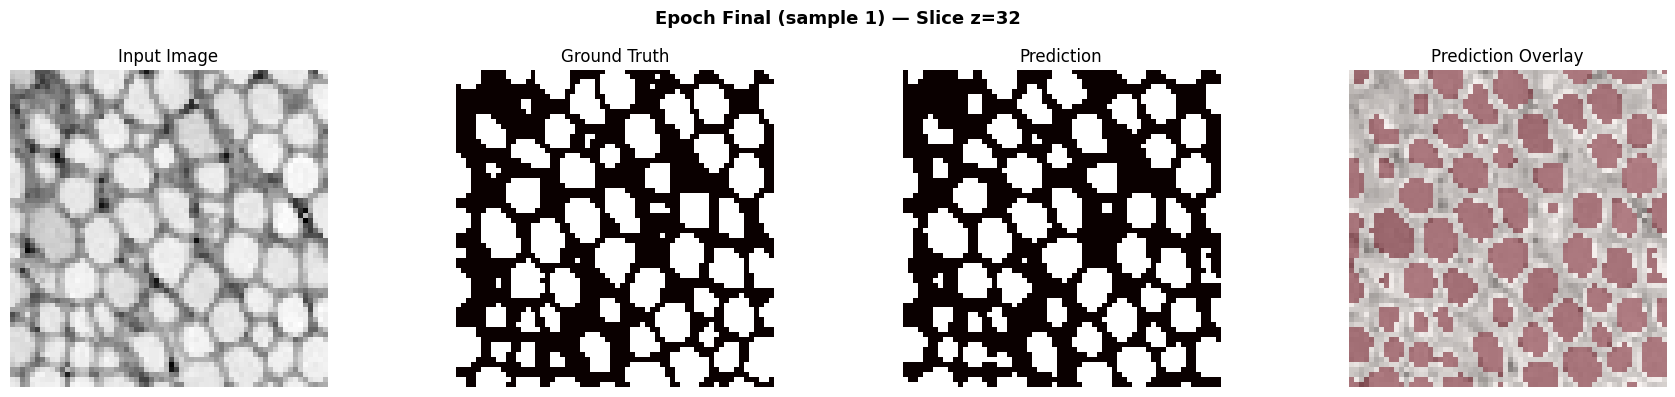

Sample 2 — Dice Score: 0.8781


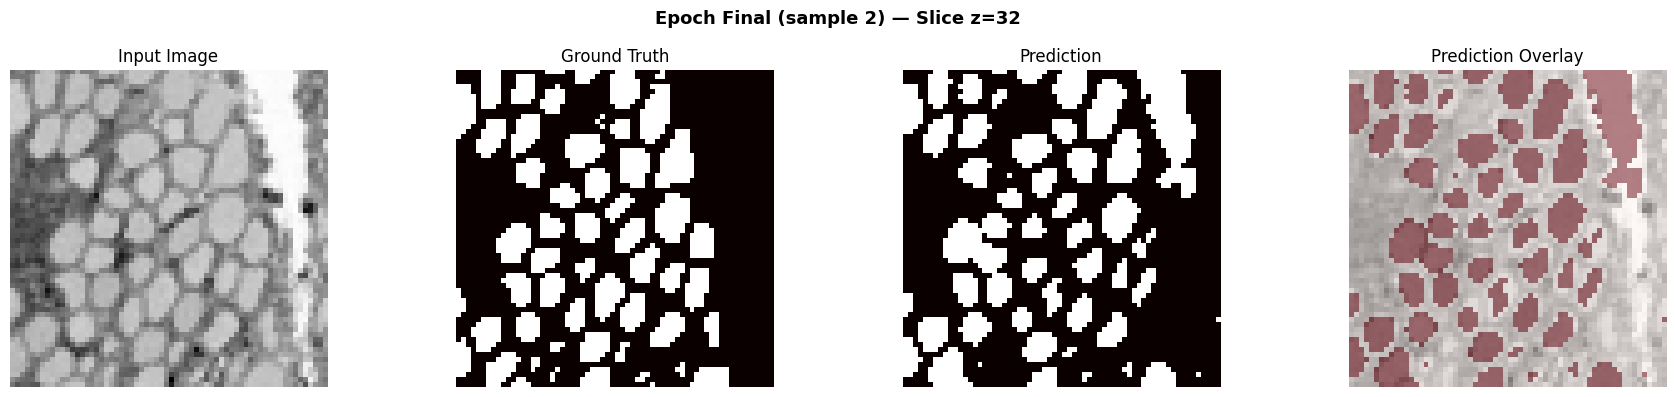

Sample 3 — Dice Score: 0.8970


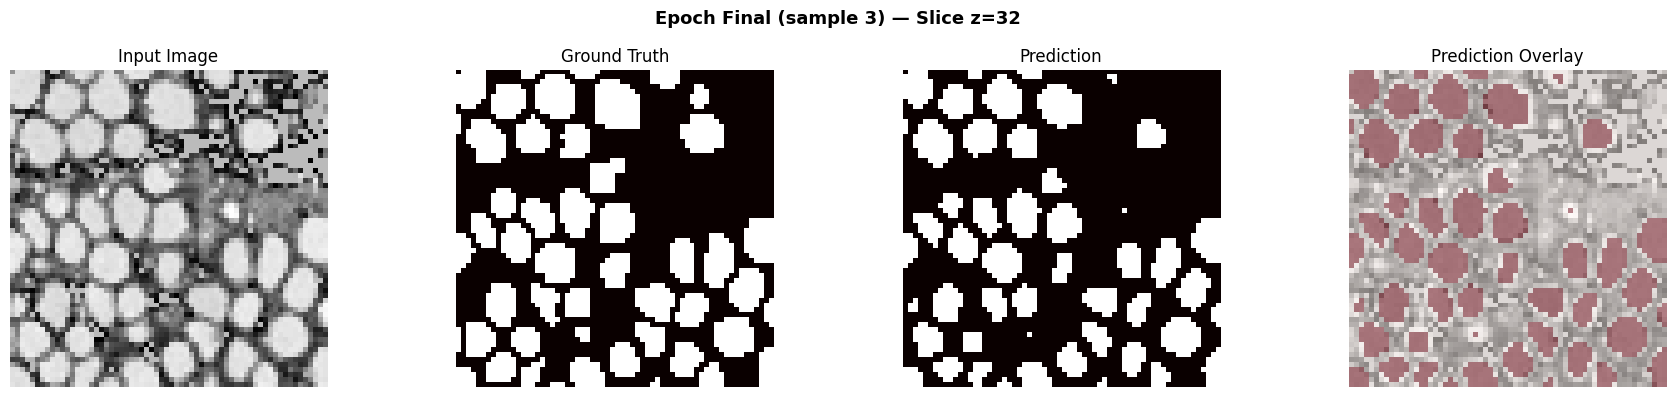

Sample 4 — Dice Score: 0.8642


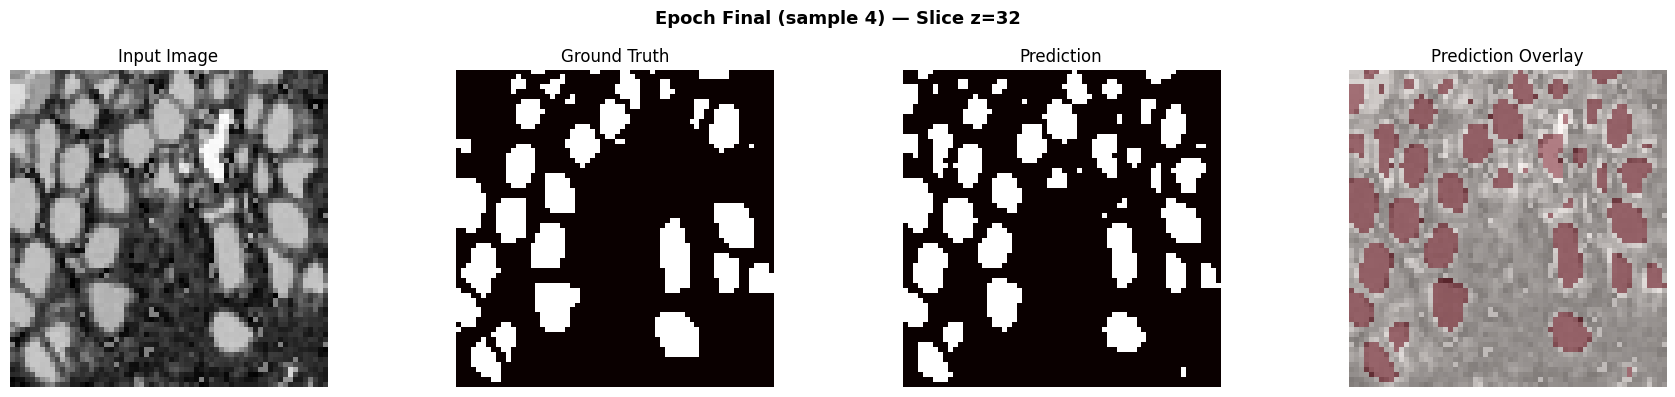


✅ Visualisation complete


In [20]:
# ============================================================
# Final prediction visualisation — 4 validation samples
# ============================================================
model.eval()
val_iter = iter(val_loader)

print("Showing predictions for 4 validation batches...\n")

for i in range(4):
    try:
        vb      = next(val_iter)
        vi      = vb["image"].to(device)
        vl      = vb["label"].to(device)
        with torch.no_grad():
            vo  = model(vi)
            vp  = (torch.sigmoid(vo) > 0.5).float()

        # Compute Dice for this sample
        dice_metric.reset()
        dice_metric(y_pred=vp, y=vl)
        sample_dice = dice_metric.aggregate().item()
        dice_metric.reset()

        print(f"Sample {i+1} — Dice Score: {sample_dice:.4f}")
        visualize_batch_prediction(vi, vl, vp, epoch=f"Final (sample {i+1})")

    except StopIteration:
        break

print("\n✅ Visualisation complete")

### 6.4 Multi-Slice Prediction Strip

For one validation volume, we show ground truth vs prediction across 8 consecutive Z-slices — giving a 3D sense of how well the segmentation holds up through the depth of the volume.

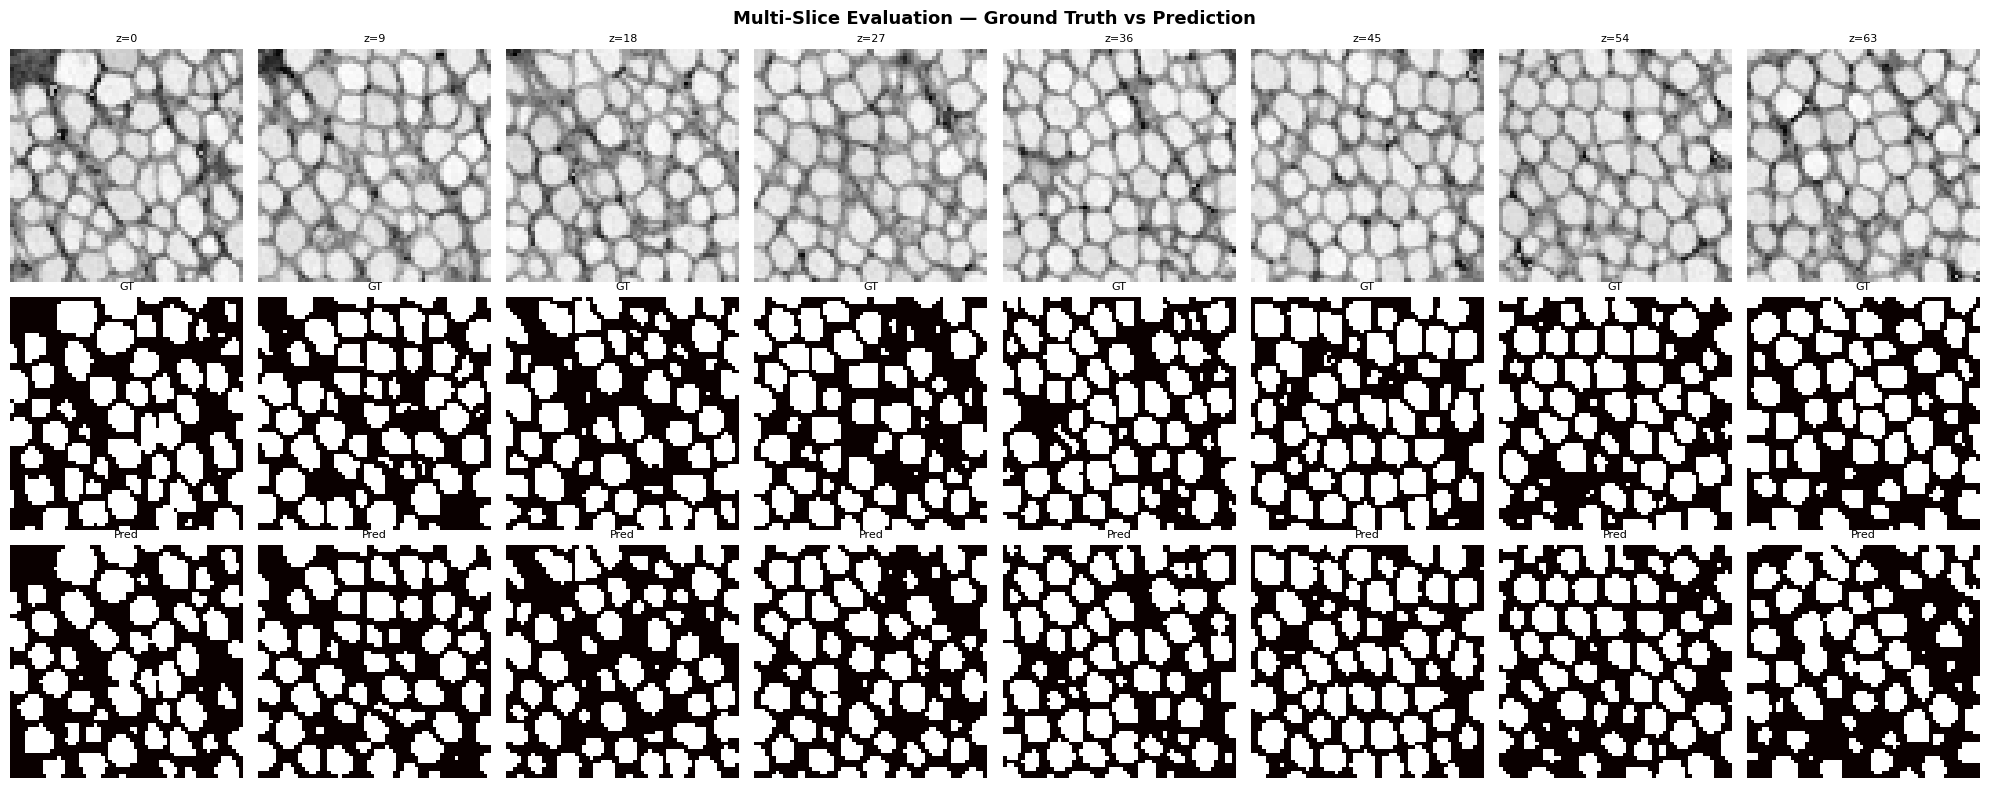

✅ Multi-slice strip complete


In [21]:
# ============================================================
# Multi-slice strip — ground truth vs prediction across Z
# ============================================================
model.eval()
vb = next(iter(val_loader))
vi = vb["image"].to(device)
vl = vb["label"].to(device)

with torch.no_grad():
    vo = model(vi)
    vp = (torch.sigmoid(vo) > 0.5).float()

img_np  = vi[0, 0].cpu().numpy()
lbl_np  = vl[0, 0].cpu().numpy()
pred_np = vp[0, 0].cpu().numpy()
img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

depth   = img_np.shape[0]
n_show  = 8
indices = np.linspace(0, depth - 1, n_show, dtype=int)

fig, axes = plt.subplots(3, n_show, figsize=(2.5 * n_show, 8))
fig.suptitle("Multi-Slice Evaluation — Ground Truth vs Prediction",
             fontsize=13, fontweight='bold')

for col, idx in enumerate(indices):
    axes[0, col].imshow(img_np[idx],  cmap="gray");  axes[0, col].set_title(f"z={idx}", fontsize=8); axes[0, col].axis("off")
    axes[1, col].imshow(lbl_np[idx],  cmap="hot");   axes[1, col].set_title("GT",       fontsize=8); axes[1, col].axis("off")
    axes[2, col].imshow(pred_np[idx], cmap="hot");   axes[2, col].set_title("Pred",     fontsize=8); axes[2, col].axis("off")

for row, ylabel in enumerate(["Image", "Ground Truth", "Prediction"]):
    axes[row, 0].set_ylabel(ylabel, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Multi-slice strip complete")

---
## Summary

| Component | Choice | Rationale |
|---|---|---|
| Architecture | 3D U-Net (5 levels) | Proven SOTA for 3D biomedical segmentation; skip connections preserve spatial detail |
| Loss function | Dice Loss | Handles severe class imbalance (~4.74% foreground) |
| Optimizer | Adam (lr=1e-3) | Fast, robust adaptive gradient method |
| LR Schedule | ReduceLROnPlateau | Automatic fine-tuning when learning plateaus |
| Patch size | 64×64×64 | GPU-memory safe; covers several nuclei per crop |
| Augmentation | Flip + Rotate + Intensity | Matches biological symmetries and imaging variability |
| Metric | Dice Score | Directly measures segmentation overlap quality |

### Result
**Best Validation Dice Score: 0.8718** — well above the 0.7 threshold considered clinically useful for nucleus segmentation.

### Possible next steps
- Train for more epochs (100–200) or with cosine annealing scheduler
- Use sliding window inference on full-resolution volumes (MONAI `sliding_window_inference`)
- Add instance segmentation post-processing (watershed on binary mask)
- Try nnU-Net for automatic hyperparameter optimisation
- Apply to the full NucMM dataset (mouse cortex EM volumes)